# Point-OCR 全流程（AutoDL / Unsloth）

按顺序执行每个代码块。本 notebook 覆盖：

1. 环境与路径  
2. 合成数据（HTML → 准星监督对）  
3. **train / val / test** 划分  
4. Unsloth Stage A 训练  
5. 验证集指标 + **测试集 5 例可视化**（图 + 模型输出）  
6. （可选）导出提示  

详细命令备忘：`docs/AUTODL.md` · Unsloth：`docs/UNSLOTH.md`

> 需要 **Linux + NVIDIA GPU** 才能训练/推理；造数据在 CPU 上也可跑（需 Playwright Chromium）。


## 0. 定位仓库根目录

后面所有相对路径都相对于仓库根。若在 `notebooks/` 下打开本文件，会自动 `chdir` 到上一级。


In [1]:
from pathlib import Path
import os, sys, json

ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
print("ROOT =", ROOT)
print("cwd  =", Path.cwd())


ROOT = /home/derek_qxc/workspace/ocr-finetuning/Point-conditioned-OCR-finetuning
cwd  = /home/derek_qxc/workspace/ocr-finetuning/Point-conditioned-OCR-finetuning


## 0.1 AutoDL 镜像（弱网必做）

先配置 PyPI / HuggingFace / Playwright 镜像再装包。

In [ ]:
import os
env = {
  'UV_INDEX_URL': 'https://mirrors.aliyun.com/pypi/simple',
  'UV_EXTRA_INDEX_URL': 'https://pypi.tuna.tsinghua.edu.cn/simple',
  'PIP_INDEX_URL': 'https://mirrors.aliyun.com/pypi/simple',
  'HF_ENDPOINT': 'https://hf-mirror.com',
  'PLAYWRIGHT_DOWNLOAD_HOST': 'https://npmmirror.com/mirrors/playwright',
  'GITHUB_PROXY': 'https://ghproxy.net',
}
os.environ.update(env)
for k,v in env.items():
    print(f'{k}={v}')


## 1. 环境检查

- `uv` 管理依赖；训练前需 `uv pip install unsloth`（CUDA 主机）  
- Chromium **只用于** HTML 渲染造数据，不是训练框架


In [ ]:
!uv --version
!nvidia-smi -L || echo "(无 GPU：仍可造数据；训练/可视化推理请换 CUDA 机器)"


In [ ]:
# 首次环境（按需取消注释）
# !uv sync --extra dev --extra synth
# !uv run playwright install chromium
# !uv sync --extra train
# !uv pip install unsloth
# !uv pip install jupyter ipykernel matplotlib
print("环境步骤按需执行")


## 2. 生成合成监督数据

管线：模板 HTML（`data-block-id`）→ Playwright 截图 → **文字墨迹 bbox** → 在块内做**角落/边缘分层采样**画准星 → ShareGPT JSONL。

准星采样已改为覆盖四角与左右端（适配横向长、纵向窄的文本行），不再挤在正中心。


In [ ]:
# 造数（首次或改模板后重跑；可加 --noise）
!uv run python data/scripts/build_synth_batch.py \
  --out data/processed/synth \
  --seed 0 \
  --r-min 3 --r-max 5 \
  --negatives 4

from point_ocr.dataset_format import load_jsonl
rows = load_jsonl(ROOT / "data/processed/synth/point_sharegpt.jsonl")
print("total pairs =", len(rows))
# 看一眼 region 分布
from collections import Counter
regs = Counter((r.get("metadata") or {}).get("region") for r in rows if not (r.get("metadata") or {}).get("is_negative"))
print("positive region counts:", dict(regs.most_common(12)))


## 3. 划分 train / val / test

默认 **90% / 5% / 5%**，打乱后切分，写出：

- `data/splits/train.jsonl` — 给 Unsloth 训练  
- `data/splits/val.jsonl` — 指标监控  
- `data/splits/test.jsonl` — 最终目视 + 指标（训练不可见）


In [ ]:
!uv run python data/scripts/split_train_val_test.py \
  --input data/processed/synth/point_sharegpt.jsonl \
  --out-dir data/splits \
  --train-frac 0.90 --val-frac 0.05 --test-frac 0.05 \
  --seed 42

print((ROOT / "data/splits/split_meta.json").read_text())


## 4. Unsloth 冒烟加载基座

确认 `ATH-MaaS/OvisOCR2` 能被 `FastVisionModel` 加载。失败见 `docs/UNSLOTH.md`。


In [ ]:
# !uv run python train/unsloth_stage_a.py --smoke-load-only --model ATH-MaaS/OvisOCR2
print("取消注释上一行做兼容性检查（需 GPU + unsloth）")


## 5. Stage A 训练（POINT QLoRA）

默认冻 vision。建议用 `tmux` 跑全量；下面先给一个可打断的小步调试命令。


In [ ]:
# 调试小跑（可先跑通）
# !uv run python train/unsloth_stage_a.py \
#   --data data/splits/train.jsonl \
#   --out checkpoints/stage_a_point_unsloth \
#   --max-samples 128 --max-steps 50

# 全量训练：
# !uv run python train/unsloth_stage_a.py \
#   --data data/splits/train.jsonl \
#   --out checkpoints/stage_a_point_unsloth

print("取消注释以开训；产出 checkpoints/stage_a_point_unsloth/lora_adapter")


## 6. 验证集快速打分（可选）

用仓库指标脚本对 val 的「预测 JSONL」打分。若还没有模型预测，可先跳过，直接做第 7 步目视。

完整离线评测也可：`eval/run_eval.py`（vLLM 后端）。


In [ ]:
from point_ocr.metrics import EvalExample, evaluate_examples, looks_like_over_extraction
print("metrics ready:", evaluate_examples([
    EvalExample("demo", "hello", "hello", False)
]).to_dict())


## 7. 测试集目视：抽出若干张，成对显示「带准星图 | GT / 模型输出」

- **加载精度**：默认 **bf16**（与 Stage A `--no-4bit` 训练一致）。`LOAD_IN_4BIT=True` 只用于显存不够时的应急，定位会变差。  
- **数据**：`TEST_JSONL` 可切到合成 test、真实整窗 `point_sharegpt.jsonl`、或 **去浏览器壳** 的 `point_sharegpt_nochrome.jsonl`。  
- **Batch-1 解码**：`max_new_tokens=256` + EOS/`stop_strings`；展示 **PRED (cleaned)**，泄漏时额外显示 raw。  

请先确认 `ADAPTER_DIR`；若不存在则只展示图 + GT。


picked 16 | RUN_INFER=True | adapter=/home/derek_qxc/workspace/ocr-finetuning/Point-conditioned-OCR-finetuning/checkpoints/20260916_092649_stage_a/adapter_final
POINT decode: max_new_tokens=256, stop+format_leak cleanup on
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/derek_qxc/workspace/ocr-finetuning/Point-conditioned-OCR-finetuning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.4: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 4060 Laptop GPU. Num GPUs = 1. Max memory: 7.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:01<00:00, 460.95it/s] 


loaded adapter /home/derek_qxc/workspace/ocr-finetuning/Point-conditioned-OCR-finetuning/checkpoints/20260916_092649_stage_a/adapter_final


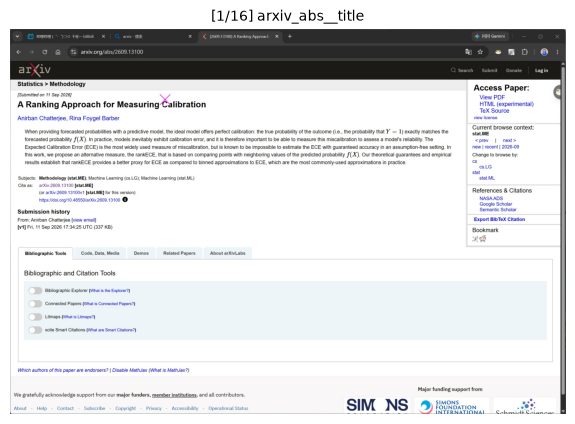

**GT**
```
A Ranking Approach for Measuring Calibration
```

**PRED (cleaned)**
```
arXiv

Q Search Submit Donate Log in
```

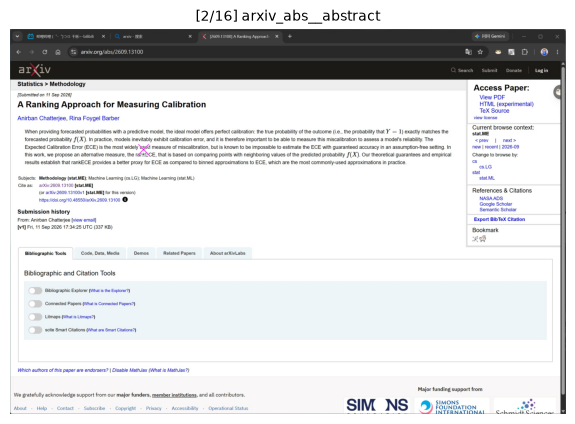

**GT**
```
When providing forecasted probabilities with a predictive model, the ideal model offers perfect calibration: the true probability of the outcome (i.e., the probability that $Y = 1$) exactly matches the forecasted probability $f(X)$. In practice, models inevitably exhibit calibration error, and it is therefore important to be able to measure this miscalibration to assess a model's reliability. The Expected Calibration Error (ECE) is the most widely used measure of miscalibration, but is known to be impossible to estimate the ECE with guaranteed accuracy in an assumption-free setting. In this work, we propose an alternative measure, the rankECE, that is based on comparing points with neighboring values of the predicted probability $f(X)$. Our theoretical guarantees and empirical results establish that rankECE provides a better proxy for ECE as compared to binned approximations to ECE, which are the most commonly-used approximations in practice.
```

**PRED (cleaned)**
```
arXiv
```

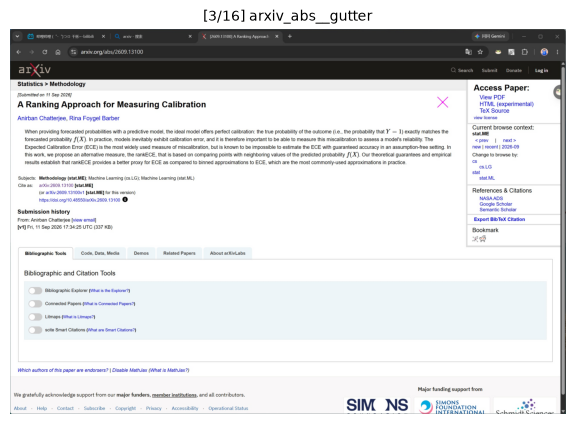

**GT**
```
∅
```

**PRED (cleaned)**
```
arXiv

Q Search Submit Donate Log in
```

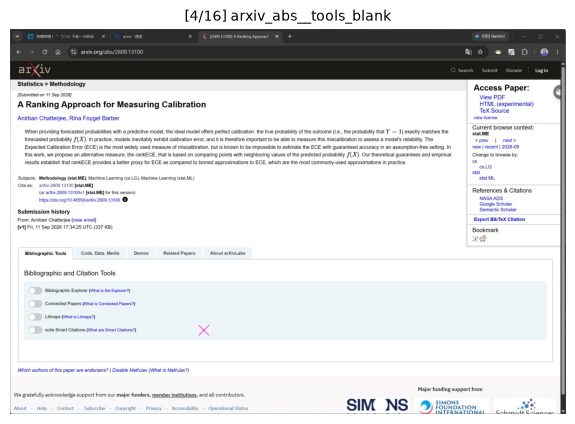

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

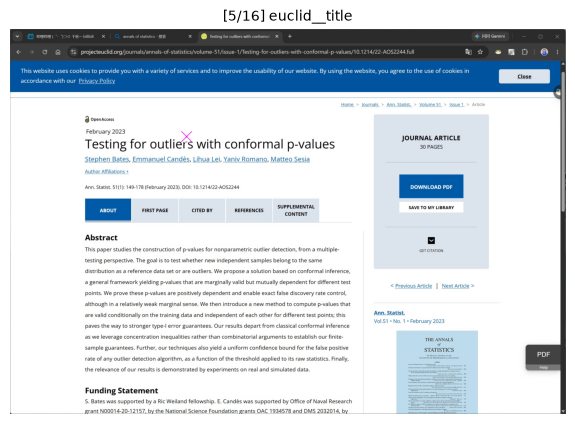

**GT**
```
Testing for outliers with conformal p-values
```

**PRED (cleaned)**
```
∅
```

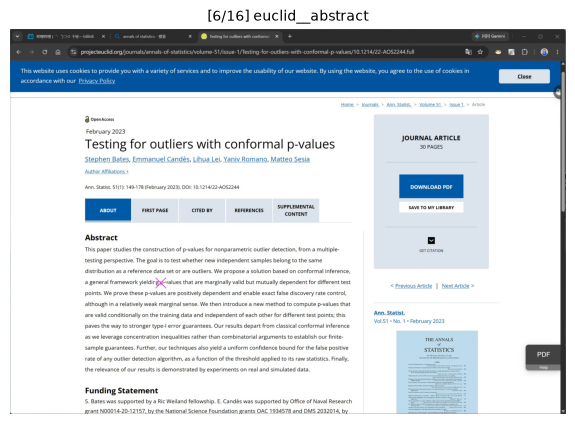

**GT**
```
This paper studies the construction of p-values for nonparametric outlier detection, from a multiple-testing perspective. The goal is to test whether new independent samples belong to the same distribution as a reference data set or are outliers. We propose a solution based on conformal inference, a general framework yielding p-values that are marginally valid but mutually dependent for different test points. We prove these p-values are positively dependent and enable exact false discovery rate control, although in a relatively weak marginal sense. We then introduce a new method to compute p-values that are valid conditionally on the training data and independent of each other for different test points; this paves the way to stronger type-I error guarantees. Our results depart from classical conformal inference as we leverage concentration inequalities rather than combinatorial arguments to establish our finite-sample guarantees. Further, our techniques also yield a uniform confidence bound for the false positive rate of any outlier detection algorithm, as a function of the threshold applied to its raw statistics. Finally, the relevance of our results is demonstrated by experiments on real and simulated data.
```

**PRED (cleaned)**
```
S. Bates was supported by a Ric Weiland fellowship. E. Candès was supported by Office of Naval Research grant N00014-20-12157, by the National Science Foundation grants OAC 1934578 and DMS 2032014, by
```

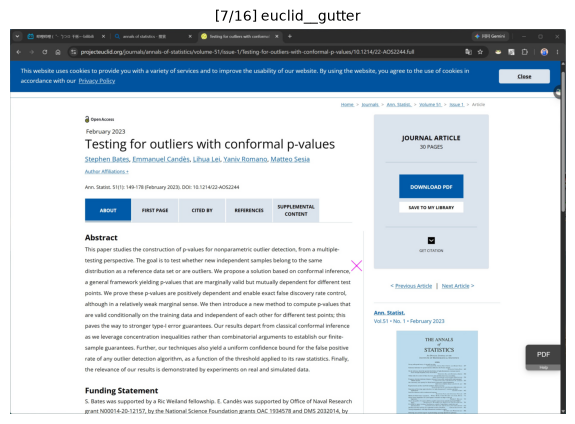

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

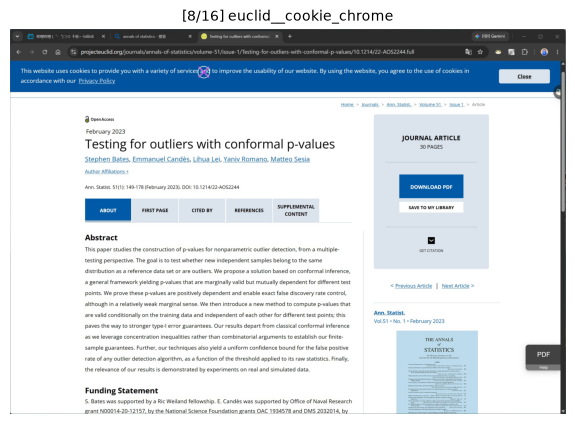

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

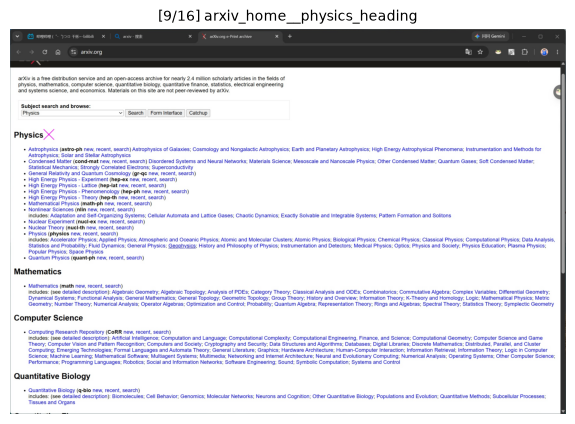

**GT**
```
Physics
```

**PRED (cleaned)**
```
arXiv is a free distribution service and an open-access archive for nearly 2.4 million scholarly articles in the fields of physics, mathematics, computer science, quantitative biology, quantitative finance, statistics, electrical engineering and systems science, and economics. Materials on this site are not peer-reviewed by arXiv.
```

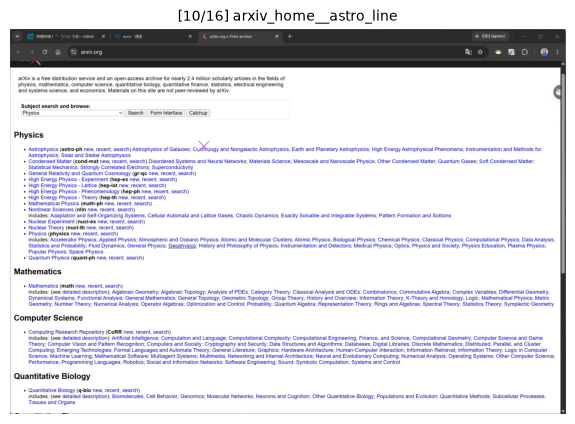

**GT**
```
Astrophysics (**astro-ph** new, recent, search) Astrophysics of Galaxies; Cosmology and Nongalactic Astrophysics; Earth and Planetary Astrophysics; High Energy Astrophysical Phenomena; Instrumentation and Methods for Astrophysics; Solar and Stellar Astrophysics
```

**PRED (cleaned)**
```
arXiv is a free distribution service and an open-access archive for nearly 2.4 million scholarly articles in the fields of physics, mathematics, computer science, quantitative biology, quantitative finance, statistics, electrical engineering and systems science, and economics. Materials on this site are not peer-reviewed by arXiv.
```

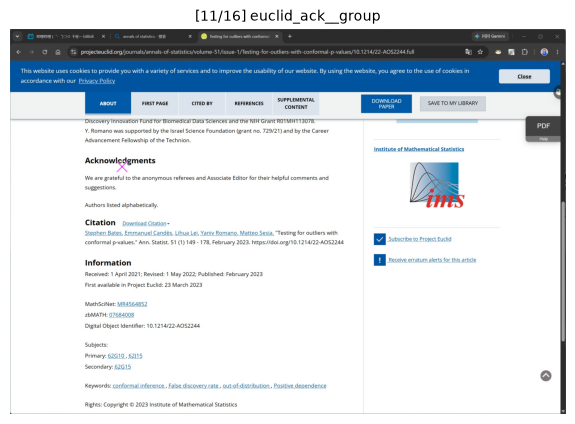

**GT**
```
## Acknowledgments

We are grateful to the anonymous referees and Associate Editor for their helpful comments and suggestions.
```

**PRED (cleaned)**
```
∅
```

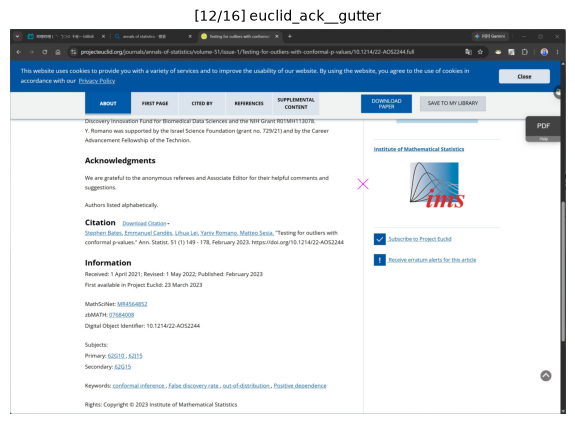

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

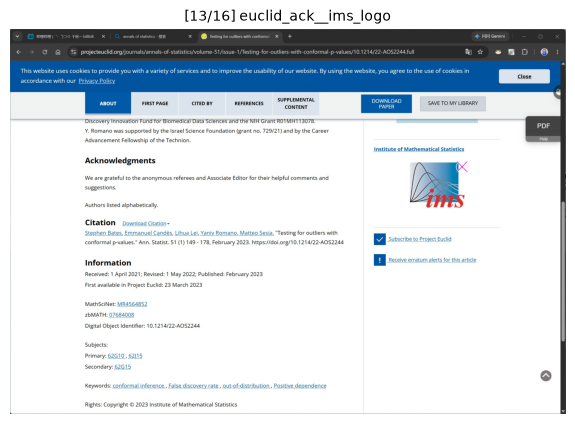

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

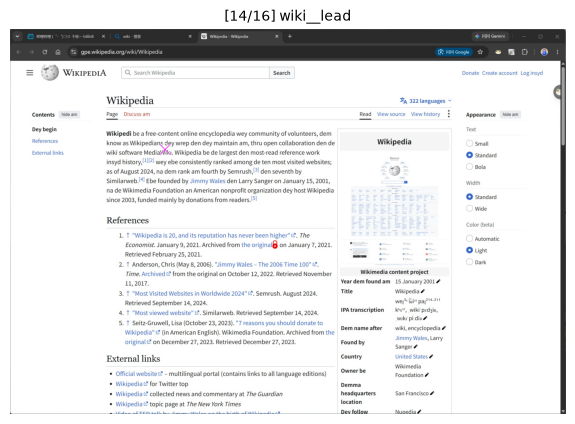

**GT**
```
Wikipedi se a free-content online encyclopedia wey community of volunteers, dem know as Wikipedians dey wrep den dey maintain am, thru open collaboration den de wiki software MediaWiki. Wikipedia be de largest den most-read reference work insyd history. wey ebe consistently ranked among de ten most visited websites; as of August 2024, na dem rank am fourth by Semrush, den seventh by Similarweb. Ebe founded by Jimmy Wales den Larry Sanger on January 15, 2001, na de Wikimedia Foundation an American nonprofit organization dey host Wikipedia since 2003, funded mainly by donations from readers.
```

**PRED (cleaned)**
```
∅
```

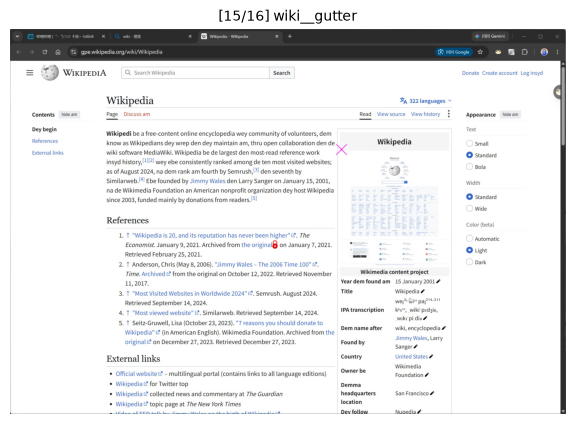

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

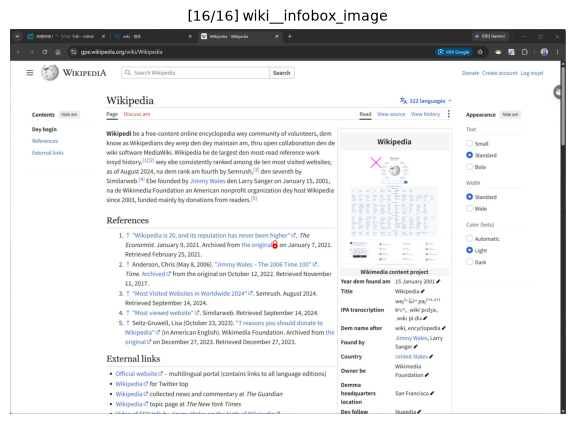

**GT**
```
∅
```

**PRED (cleaned)**
```
∅
```

In [2]:
from IPython.display import display, Markdown
from PIL import Image
import matplotlib.pyplot as plt
import torch
from point_ocr.viz_test import (
    DEFAULT_POINT_MAX_NEW_TOKENS,
    format_pred_markdown,
    generate_point_text,
    pick_test_examples,
    row_image_and_target,
)
from point_ocr.prompts import POINT_PROMPT

# --- 数据：三选一 ---
# TEST_JSONL = ROOT / "data/splits_stage_a2b/val.jsonl"          # 合成 val
# TEST_JSONL = ROOT / "data/real_world_sample/point_sharegpt.jsonl"  # 真实整窗（含浏览器壳）
TEST_JSONL = ROOT / "data/real_world_sample/point_sharegpt_nochrome.jsonl"  # 去浏览器壳

# Newest curriculum/stage adapter under checkpoints/
_cands = sorted(
    list((ROOT / "checkpoints").glob("*_stage_a/adapter_final"))
    + list((ROOT / "checkpoints").glob("*_curriculum_*/adapter_final")),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
ADAPTER_DIR = _cands[0] if _cands else ROOT / "checkpoints/stage_a_point_unsloth/lora_adapter"
BASE_MODEL = "ATH-MaaS/OvisOCR2"
N_SHOW = 16
SEED = 0
# 真实 probe 含空例；合成目视可改 True
PREFER_POSITIVE = False
# True = 跑推理；False = 只看图+GT（无需 GPU）
RUN_INFER = ADAPTER_DIR.exists()
# 与训练对齐：bf16。仅当 8G 装不下时再改 True（定位会变差）
LOAD_IN_4BIT = False

examples = pick_test_examples(
    TEST_JSONL, n=N_SHOW, seed=SEED, prefer_positive=PREFER_POSITIVE
)
print(f"picked {len(examples)} | RUN_INFER={RUN_INFER} | adapter={ADAPTER_DIR}")
print(f"LOAD_IN_4BIT={LOAD_IN_4BIT} | TEST_JSONL={TEST_JSONL}")
print(f"POINT decode: max_new_tokens={DEFAULT_POINT_MAX_NEW_TOKENS}, stop+format_leak cleanup on")

_POINT_MODEL = None
_POINT_TOK = None

def predict_unsloth(image: Image.Image, prompt: str):
    """Return CleanedPrediction (cleaned + raw + format_leak flag)."""
    global _POINT_MODEL, _POINT_TOK
    if _POINT_MODEL is None:
        from unsloth import FastVisionModel
        load_kwargs = dict(
            load_in_4bit=LOAD_IN_4BIT,
            use_gradient_checkpointing="unsloth",
        )
        if not LOAD_IN_4BIT:
            load_kwargs["dtype"] = (
                torch.bfloat16
                if torch.cuda.is_available() and torch.cuda.is_bf16_supported()
                else torch.float16
            )
        model, tok = FastVisionModel.from_pretrained(BASE_MODEL, **load_kwargs)
        if ADAPTER_DIR.exists():
            from peft import PeftModel
            model = PeftModel.from_pretrained(model, str(ADAPTER_DIR))
            print("loaded adapter", ADAPTER_DIR, "| 4bit=", LOAD_IN_4BIT)
        else:
            print("using base model (zero-shot) | 4bit=", LOAD_IN_4BIT)
        FastVisionModel.for_inference(model)
        _POINT_MODEL, _POINT_TOK = model, tok

    return generate_point_text(
        _POINT_MODEL,
        _POINT_TOK,
        image,
        prompt,
        max_new_tokens=DEFAULT_POINT_MAX_NEW_TOKENS,
        clean=True,
    )

for i, row in enumerate(examples):
    img_path, gt, sid = row_image_and_target(row)
    img = Image.open(img_path).convert("RGB")
    pred_md = ""
    if RUN_INFER:
        try:
            pred = predict_unsloth(img, POINT_PROMPT)
            pred_md = format_pred_markdown(pred)
        except Exception as e:
            pred_md = f"**PRED**\n```\n[infer error] {e}\n```"
    else:
        pred_md = "**PRED**\n```\n(未推理：将 RUN_INFER=True 或先完成训练以加载 adapter)\n```"

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"[{i+1}/{len(examples)}] {sid}", fontsize=10)
    plt.show()
    display(Markdown(f"**GT**\n```\n{gt if gt else '∅'}\n```\n\n{pred_md}"))


## 8. （可选）合并 LoRA 并导出 GGUF

见 `export/README.md` 与 `docs/AUTODL.md` 第 6 节。


In [ ]:
# !uv run python export/merge_lora.py \
#   --base ATH-MaaS/OvisOCR2 \
#   --adapter checkpoints/stage_a_point_unsloth/lora_adapter \
#   --out exports/OvisOCR2-Point-hf
print("导出按需取消注释")


## 验收提醒

- 准星应落在目标文字上（含角落/行首行尾），预测应接近 GT 单块  
- `over-extraction`（整页倾倒）应明显低于零样本基座  
- 负例（准星在空白/任务栏）应接近空串
